In [1]:
import sys
# import matplotlib.pyplot as plt
import importlib
# sys.path.append('C:/Users/kanoutem/Desktop/Doctorat/Codes/feat_select/RSR_TS')
# sys.path.append('/home/mkanoute/Desktop/postdoc/RSR_TS')

# sys.path.append('C:/Users/kanoutem/Desktop/Doctorat/Codes/feat_select/RSR_TS/Clustering')
# sys.path.append('/home/mkanoute/Desktop/postdoc/RSR_TS/Clustering')

import numpy as np

from scipy.optimize import minimize
import torch
import pandas as pd
from sklearn.preprocessing import StandardScaler

from grad_fs_elem import *
import matplotlib.pyplot as plt

In [2]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import confusion_matrix
from sklearn.metrics import f1_score
from sklearn.metrics import accuracy_score

# Données générées

$
f_1 \sim \mathcal{N}(1,5^2),
f_2 \sim \mathcal{N}(0,2^2),
f_3 \sim \mathcal{N}(2,7^2),
f_4 \sim \mathcal{N}(5,3^2),
f_5 \sim \mathcal{N}(0,1),$  \
$f_6 \sim \mathcal{N}(0,0.3^2),
f_7 \sim \mathcal{N}(3,2^2),
f_8 \sim \mathcal{N}(11,1), 
f_9 \sim \mathcal{N}(0.3,0.3^2),
f_{10} \sim \mathcal{N}(0,0.7^2).
.
$

## Regression

 For regression, 3 continuous outputs are defined 
\begin{gather*} 
Y_1 =  cos(sin(f_8)) + \epsilon_{Y_1} ~\text{ where } ~ \epsilon_{Y_1} \sim \mathcal{N}(0, 0.1^2) \\ 
Y_2 =  f_1^2 sin(\dfrac{f_3}{f_1}) + \epsilon_{Y_2} ;  ~\text{ where } ~ \epsilon_{Y_2} \sim \mathcal{N}(0, 0.1^2) \\
Y_3 =  log(\dfrac{1}{f_1^2} + f_5^2 + 1) + \epsilon_{Y_3} ~\text{ where } ~ \epsilon_{Y_3} \sim \mathcal{N}(0, 0.1^2)
\end{gather*}

In [3]:
def generate_data_func2(random_state, n_samples, output_consid = "all"):
    print("****************** dans nonlin ******************")
    obj_data = {}
    np.random.seed(random_state)
    obj_data["f1"] = np.random.normal(1, 5, n_samples)
    obj_data["f2"] = np.random.normal(0, 2, n_samples)
    obj_data["f3"] = np.random.normal(2, 7, n_samples)
    obj_data["f4"] = np.random.normal(5, 3, n_samples)
    obj_data["f5"] = np.random.normal(0, 1, n_samples)
    obj_data["f6"] = np.random.normal(0, 0.3, n_samples)
    obj_data["f7"] = np.random.normal(3, 2, n_samples)
    obj_data["f8"] = np.random.normal(11, 1, n_samples)
    obj_data["f9"] = np.random.normal(0.3, 0.3, n_samples)
    obj_data["f10"] = np.random.normal(0, 0.7, n_samples)
    
    if output_consid == "Y1":
        obj_data["Y1"] = np.cos(np.sin(obj_data["f8"])) + np.random.normal(0, 0.1, n_samples)
    elif output_consid == "Y2":
        obj_data["Y2"] = (obj_data["f1"]**2)*np.sin(obj_data["f3"]/obj_data["f1"]) +  np.random.normal(0, 0.1, n_samples)
    elif output_consid == "Y3":
        obj_data["Y3"] = np.log1p(1/(obj_data["f1"]**2) + obj_data["f5"]**2) + np.random.normal(0, 0.1, n_samples)
    elif output_consid == "all":
        obj_data["Y1"] = np.cos(np.sin(obj_data["f8"])) + np.random.normal(0, 0.1, n_samples)
        obj_data["Y2"] = (obj_data["f1"]**2)*np.sin(obj_data["f3"]/obj_data["f1"]) +  np.random.normal(0, 0.1, n_samples)
        obj_data["Y3"] = np.log1p(1/(obj_data["f1"]**2) + obj_data["f5"]**2) + np.random.normal(0, 0.1, n_samples)
        
    obj_data_df = pd.DataFrame(obj_data)
    return obj_data_df, None

In [4]:
random_state, n_samples = 5, 1000

data_df_mono, _ = generate_data_func2(random_state, n_samples, output_consid = "Y1")
data_df_multi, _ = generate_data_func2(random_state, n_samples, output_consid = "all")

****************** dans nonlin ******************
****************** dans nonlin ******************


In [5]:
data_df_multi.shape


(1000, 13)

In [6]:

X0_mono, y0_mono = data_df_mono.iloc[:, :-1].values, data_df_mono.iloc[:, [-1]].values
X0_multi, y0_multi = data_df_multi.iloc[:, :-3].values, data_df_multi.iloc[:, -3:].values

sc_x_mono, sc_x_multi, sc_y_mono, sc_y_multi = StandardScaler(), StandardScaler(), StandardScaler(), StandardScaler()       
X_mono, X_multi = sc_x_mono.fit_transform(X0_mono), sc_x_multi.fit_transform(X0_multi)
y_mono, y_multi = sc_y_mono.fit_transform(y0_mono), sc_y_multi.fit_transform(y0_multi)

In [44]:
activ_func, nb_neurons = "tanh", 400

params_optim = {"eps": 1e-8, "maxiter": 400, "maxfun": 15000, "maxls": 20, "maxcor": 100}

lbda_mono, C_mono  = 1e-2, 1e1
grad_FS_ELM_impl_mono = grad_FS_ELM(lbda_mono, C_mono, activ_func, nb_neurons, params_optim = params_optim)

lbda_multi, C_multi  = 1e-2, 1e1
grad_FS_ELM_impl_multi = grad_FS_ELM(lbda_multi, C_multi, activ_func, nb_neurons, params_optim = params_optim)

In [45]:
alpha_min_mono = grad_FS_ELM_impl_mono.fit(X_mono, y_mono, type_optim = "grad_variant")

self.x0_user (10,)
0 tensor(330.5602, dtype=torch.float64) None
1 tensor(143.3582, dtype=torch.float64) 1.0
2 tensor(129.9410, dtype=torch.float64) 0.03125
3 tensor(125.4472, dtype=torch.float64) 0.001953125
4 tensor(118.5776, dtype=torch.float64) 0.015625


/home/mkanoute/Desktop/postdoc/RSR_TS/grad_fs_elem.py:74: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  alpha = torch.tensor(alpha0, dtype=torch.float64, device=self.device)


5 tensor(120.4349, dtype=torch.float64) 0.03125
6 tensor(120.9827, dtype=torch.float64) 0.015625
7 tensor(106.6939, dtype=torch.float64) 0.015625
8 tensor(106.4397, dtype=torch.float64) 3.814697265625e-06
9 tensor(104.7871, dtype=torch.float64) 0.00390625
10 tensor(104.5775, dtype=torch.float64) 3.814697265625e-06
11 tensor(104.3281, dtype=torch.float64) 0.001953125
12 tensor(104.1205, dtype=torch.float64) 3.814697265625e-06
13 tensor(103.9941, dtype=torch.float64) 7.62939453125e-06
14 tensor(103.9847, dtype=torch.float64) 3.814697265625e-06
15 tensor(103.9701, dtype=torch.float64) 3.814697265625e-06
16 tensor(103.9745, dtype=torch.float64) 7.62939453125e-06
Arrêt : variation relative de la fonction (ftol)


In [46]:
alpha_min_multi = grad_FS_ELM_impl_multi.fit(X_multi, y_multi, type_optim = "grad_variant")


self.x0_user (10,)
0 tensor(767.6306, dtype=torch.float64) None
1 tensor(554.0064, dtype=torch.float64) 1.0
2 tensor(526.4444, dtype=torch.float64) 0.00048828125
3 tensor(529.0622, dtype=torch.float64) 0.0078125
4 tensor(510.0090, dtype=torch.float64) 0.0078125
5 tensor(504.0641, dtype=torch.float64) 0.001953125
6 tensor(486.9526, dtype=torch.float64) 0.001953125
7 tensor(478.7692, dtype=torch.float64) 0.0009765625
8 tensor(405.9569, dtype=torch.float64) 0.015625
9 tensor(400.1190, dtype=torch.float64) 0.00048828125
10 tensor(343.5603, dtype=torch.float64) 0.00390625
11 tensor(343.8939, dtype=torch.float64) 0.000244140625
Arrêt : variation relative de la fonction (ftol)


In [47]:
cols = np.array(list(data_df_mono)[:-y0_mono.shape[1]])

weights_var_mono = alpha_min_mono["x"]
weights_var_ord_ind_mono = np.argsort(-weights_var_mono)
Cols_ord_with_weights_mono = pd.DataFrame({"ranked vars": cols[weights_var_ord_ind_mono], "weights": weights_var_mono[weights_var_ord_ind_mono]})

weights_var_multi = alpha_min_multi["x"]
weights_var_ord_ind_multi = np.argsort(-weights_var_multi)
Cols_ord_with_weights_multi = pd.DataFrame({"ranked vars": cols[weights_var_ord_ind_multi], "weights": weights_var_multi[weights_var_ord_ind_multi]})

In [48]:
Cols_ord_with_weights_mono

,ranked vars,weights
0,f8,0.996945
1,f9,0.564462
2,f5,0.385012
3,f4,0.295227
4,f3,0.184473
5,f10,0.110065
6,f7,0.108477
7,f2,0.001078
8,f6,0.000000
9,f1,0.000000


In [49]:
Cols_ord_with_weights_multi

,ranked vars,weights
0,f1,1.000000
1,f3,1.000000
2,f8,0.605233
3,f5,0.152922
4,f4,0.000000
5,f2,0.000000
6,f6,0.000000
7,f7,0.000000
8,f9,0.000000
9,f10,0.000000


In [50]:
preds_sc_mono = grad_FS_ELM_impl_mono.predict(X_mono)
preds_mono = sc_y_mono.inverse_transform(preds_sc_mono)

preds_sc_multi = grad_FS_ELM_impl_multi.predict(X_multi)
preds_multi = sc_y_multi.inverse_transform(preds_sc_multi)

In [52]:
mean_squared_error(y0_mono.ravel(), preds_mono.ravel()), mean_squared_error(y0_multi.ravel(), preds_multi.ravel())

(0.005409670817621647, 0.5624870807881017)

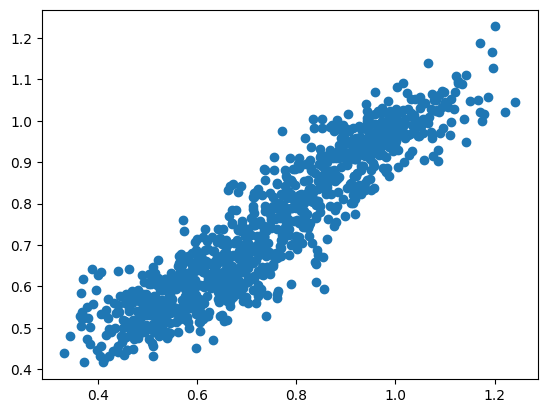

In [53]:
plt.scatter(y0_mono.ravel(), preds_mono.ravel())